## Jet Image Pre-training with Vision Transformer

This notebook sets up a self-supervised pre-training pipeline for jet images using an unlabelled HDF5 dataset.

1. **Data Inspection** – Open the HDF5 file and examine the structure/shape of the `jet` dataset (125×125×8 images with 8 channels).
2. **PyTorch Dataset** – Define `JetUnlabelledDataset`, which lazily loads jet images, converts them to `(C, H, W)` tensors, and applies zero-mean/unit-variance normalization.
3. **Train / Val Split & DataLoaders** – Split the dataset 95/5 into training and validation sets and wrap them in `DataLoader`s for batched iteration.

In [15]:
import h5py

with h5py.File('data/Dataset_Specific_Unlabelled.h5', 'r') as f:
    print("Top-level keys:", list(f.keys()))

    jet = f['jet']
    print("Type of 'jet':", type(jet))

    # If it's a dataset:
    if isinstance(jet, h5py.Dataset):
        print("Shape:", jet.shape)
        first = jet[0]
        print("First item shape:", first.shape)

    # If it's a group (folder), inspect deeper:
    if isinstance(jet, h5py.Group):
        print("Keys inside 'jet':", list(jet.keys()))

Top-level keys: ['jet']
Type of 'jet': <class 'h5py._hl.dataset.Dataset'>
Shape: (60000, 125, 125, 8)
First item shape: (125, 125, 8)


In [16]:
import h5py
import torch
from torch.utils.data import Dataset, DataLoader

class JetUnlabelledDataset(Dataset):
    def __init__(self, h5_path):
        self.h5_path = h5_path
        self.file = None  # opened lazily

        # read shape without keeping file open
        with h5py.File(h5_path, "r") as f:
            self.length = f["jet"].shape[0]

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        # open file inside worker if needed
        if self.file is None:
            self.file = h5py.File(self.h5_path, "r")
        
        x = self.file["jet"][idx]  # (125,125,8)
        x = torch.tensor(x, dtype=torch.float32)

        # convert to (C,H,W)
        x = x.permute(2, 0, 1)

        # optional: simple normalization
        x = (x - x.mean()) / (x.std() + 1e-6)

        return x

In [17]:
from torch.utils.data import random_split

dataset = JetUnlabelledDataset("data/Dataset_Specific_Unlabelled.h5")

val_size = int(0.05 * len(dataset))
train_size = len(dataset) - val_size

train_ds, val_ds = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)

## Sanity Check: Visualizing Jet Channels

Before training any model, we must verify that the input data looks reasonable.

Each jet sample has shape (8, 125, 125), meaning:
- 8 feature channels
- 125×125 spatial grid per channel

These are not RGB images. Each channel encodes detector-level physical information.
If the data contains mostly zeros, extreme outliers, or unexpected structure,
a transformer may learn meaningless patterns.

We will:
- Sample a random jet
- Visualize a few of its channels
- Inspect value ranges

This prevents silent failure during training.

Sample shape: torch.Size([8, 125, 125])
Min value: -0.08352053910493851
Max value: 25.05877685546875
Mean value: -5.371093791950443e-09
Std value: 0.9999999403953552


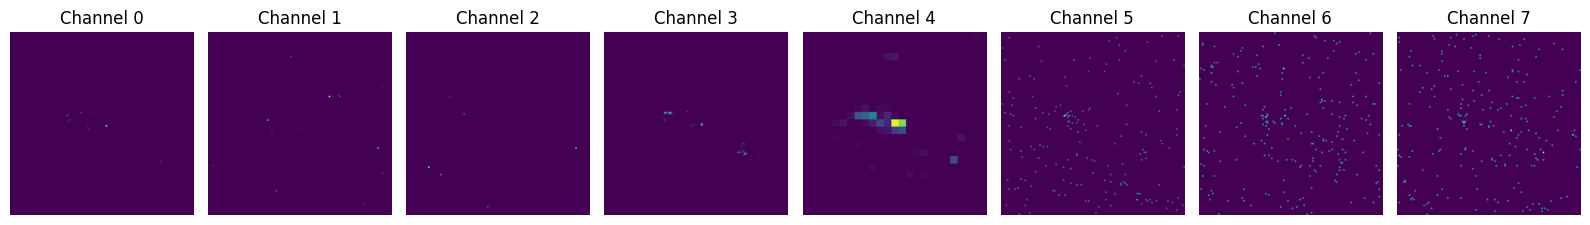

In [18]:
import matplotlib.pyplot as plt
import random

# get one random sample from training dataset
idx = random.randint(0, len(train_ds)-1)
sample = train_ds[idx]   # shape: (8,125,125)

print("Sample shape:", sample.shape)
print("Min value:", sample.min().item())
print("Max value:", sample.max().item())
print("Mean value:", sample.mean().item())
print("Std value:", sample.std().item())

# visualize first 4 channels
num_channels_to_plot = 8

fig, axes = plt.subplots(1, num_channels_to_plot, figsize=(16,4))

for i in range(num_channels_to_plot):
    axes[i].imshow(sample[i].cpu(), cmap="viridis")
    axes[i].set_title(f"Channel {i}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [19]:
import torch
import torch.nn as nn

class PatchEmbed(nn.Module):
    def __init__(self, in_ch=8, embed_dim=256, patch=5):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, embed_dim,
                              kernel_size=patch,
                              stride=patch)

    def forward(self, x):
        x = self.proj(x)          # (B, embed_dim, 25, 25)
        x = x.flatten(2)          # (B, embed_dim, 625)
        x = x.transpose(1, 2)     # (B, 625, embed_dim)
        return x

# test
patch_embed = PatchEmbed()
batch = next(iter(train_loader))

tokens = patch_embed(batch)
print("Input batch shape:", batch.shape)
print("Token shape:", tokens.shape)

Input batch shape: torch.Size([32, 8, 125, 125])
Token shape: torch.Size([32, 625, 256])


## Pretraining: Masked Autoencoder for Jet Representation Learning

We pretrain a Vision Transformer encoder on the unlabelled jet dataset using a masked reconstruction objective.

Each jet image (8 × 125 × 125) is split into 5×5 patches → 625 tokens.

During training:
- 60% of patches are randomly masked
- Encoder processes only visible patches
- A lightweight decoder reconstructs the original patches
- Loss = Mean Squared Error between reconstructed and original patches

Why this works:
The model must learn global jet structure to reconstruct missing regions.
This produces useful representations for downstream tasks like
mass regression and classification.

After pretraining, we will:
- Save encoder weights
- Fine-tune on labelled dataset
- Compare against training from scratch

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

class PatchEmbed(nn.Module):
    def __init__(self, in_ch=8, embed_dim=256, patch=5):
        super().__init__()
        self.patch = patch
        self.proj = nn.Conv2d(in_ch, embed_dim,
                              kernel_size=patch,
                              stride=patch)

    def forward(self, x):
        x = self.proj(x)                        # (B, D, 25, 25)
        B, D, H, W = x.shape
        x = x.permute(0, 2, 3, 1).contiguous()  # (B, 25, 25, D)
        x = x.reshape(B, H * W, D)              # (B, 625, D)
        return x

class Attention(nn.Module):
    def __init__(self, dim, heads=8, eps=1e-6):
        super().__init__()
        if dim % heads != 0:
            raise ValueError("dim must be divisible by heads")

        self.norm = nn.LayerNorm(dim)
        self.heads = heads
        self.head_dim = dim // heads
        self.eps = eps

        self.to_qkv = nn.Linear(dim, dim * 3, bias=False)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x):
        y = self.norm(x)
        B, N, C = y.shape

        qkv = self.to_qkv(y).reshape(B, N, 3, self.heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B, H, N, Dh)
        q, k, v = qkv[0], qkv[1], qkv[2]

        q = F.elu(q) + 1.0
        k = F.elu(k) + 1.0

        kv = torch.einsum("b h n d, b h n e -> b h d e", k, v)
        k_sum = k.sum(dim=2)  # (B, H, Dh)

        z = 1.0 / (torch.einsum("b h n d, b h d -> b h n", q, k_sum) + self.eps)
        out = torch.einsum("b h n d, b h d e, b h n -> b h n e", q, kv, z)

        out = out.transpose(1, 2).contiguous().reshape(B, N, C)
        out = self.proj(out)
        return out

class Block(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = Attention(dim)
        self.ff = nn.Sequential(
            nn.Linear(dim, dim*4),
            nn.GELU(),
            nn.Linear(dim*4, dim)
        )
        self.n2 = nn.LayerNorm(dim)

    def forward(self,x):
        x = x + self.attn(x)
        x = x + self.ff(self.n2(x))
        return x

class Encoder(nn.Module):
    def __init__(self, dim=256, depth=4):
        super().__init__()
        self.patch = PatchEmbed()
        self.pos = nn.Parameter(torch.randn(1, 625, dim))
        self.blocks = nn.Sequential(*[Block(dim) for _ in range(depth)])
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        x = self.patch(x)
        x = x + self.pos
        x = self.blocks(x)
        x = self.norm(x)
        return x

class MAE(nn.Module):
    def __init__(self, dim=256, mask_ratio=0.6):
        super().__init__()
        self.encoder = Encoder(dim)
        self.decoder = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Linear(dim, 8*5*5)
        )
        self.mask_ratio = mask_ratio
        self.patch_size = 5

    def patchify(self, imgs):
        B, C, H, W = imgs.shape
        p = self.patch_size
        h, w = H // p, W // p
        x = imgs.reshape(B, C, h, p, w, p)
        x = x.permute(0, 2, 4, 1, 3, 5).contiguous()  # (B, h, w, C, p, p)
        x = x.reshape(B, h * w, C * p * p)
        return x

    def forward(self, x):
        B = x.size(0)

        target = self.patchify(x)
        tokens = self.encoder.patch(x)

        N = tokens.size(1)
        mask_count = int(N * self.mask_ratio)

        noise = torch.rand(B, N, device=x.device)
        ids = torch.argsort(noise, dim=1)
        keep = ids[:, mask_count:]

        visible = torch.gather(
            tokens, 1,
            keep.unsqueeze(-1).expand(-1, -1, tokens.size(-1))
        )

        encoded = self.encoder.blocks(
            visible + self.encoder.pos[:, :visible.size(1)]
        )
        encoded = self.encoder.norm(encoded)

        recon_visible = self.decoder(encoded)

        target_visible = torch.gather(
            target, 1,
            keep.unsqueeze(-1).expand(-1, -1, target.size(-1))
        )

        loss = ((recon_visible - target_visible)**2).mean()
        return loss

Using device: cuda


Epoch 1/10: 100%|██████████| 1782/1782 [01:50<00:00, 16.15it/s, loss=0.0716]


Epoch 1: Train=0.1910 | Val=0.0724


Epoch 2/10: 100%|██████████| 1782/1782 [01:41<00:00, 17.52it/s, loss=0.0478]


Epoch 2: Train=0.0612 | Val=0.0515


...

Epoch 8: Train=0.0163 | Val=0.0147


Epoch 9/10: 100%|██████████| 1782/1782 [01:39<00:00, 17.95it/s, loss=0.0177] 


Epoch 9: Train=0.0138 | Val=0.0129


Epoch 10/10: 100%|██████████| 1782/1782 [01:47<00:00, 16.62it/s, loss=0.0122] 


Epoch 10: Train=0.0118 | Val=0.0108


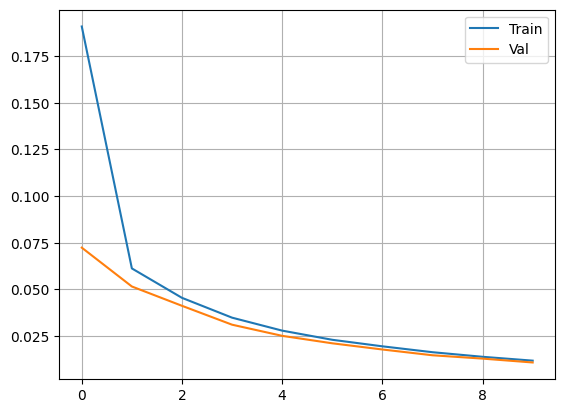

In [21]:
from tqdm import tqdm
import matplotlib.pyplot as plt

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

model = MAE().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-4)

epochs = 10
train_history = []
val_history = []

for epoch in range(epochs):
    model.train()
    train_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for batch in loop:
        if isinstance(batch, (list, tuple)):
            batch = batch[0]
        batch = batch.to(device)

        loss = model(batch)

        opt.zero_grad()
        loss.backward()
        opt.step()

        train_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    train_loss /= len(train_loader)
    train_history.append(train_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            if isinstance(batch, (list, tuple)):
                batch = batch[0]
            batch = batch.to(device)
            loss = model(batch)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_history.append(val_loss)

    print(f"Epoch {epoch+1}: Train={train_loss:.4f} | Val={val_loss:.4f}")

torch.save(model.encoder.state_dict(), "pretrained_encoder.pt")

plt.plot(train_history, label="Train")
plt.plot(val_history, label="Val")
plt.legend()
plt.grid(True)
plt.show()

In [22]:

path = "data/Dataset_Specific_labelled.h5"

def explore(name, obj):
    if isinstance(obj, h5py.Dataset):
        print(f"{name} -> DATASET shape={obj.shape} dtype={obj.dtype}")
    else:
        print(f"{name} -> GROUP")

with h5py.File(path, "r") as f:
    print("Top-level keys:", list(f.keys()))
    print("\nFull structure:\n")
    f.visititems(explore)

with h5py.File(path, "r") as f:
    jet = f["jet"][0]
    print("Jet shape:", jet.shape)

    for k in f.keys():
        if k != "jet":
            print(k, "sample value:", f[k][0])

Top-level keys: ['Y', 'jet']

Full structure:

Y -> DATASET shape=(10000, 1) dtype=float32
jet -> DATASET shape=(10000, 125, 125, 8) dtype=float32
Jet shape: (125, 125, 8)
Y sample value: [1.]


Shape: (10000,)
dtype: float32
Min: 0.0
Max: 1.0
Unique values (first 20): [0. 1.]
Number of unique values: 2


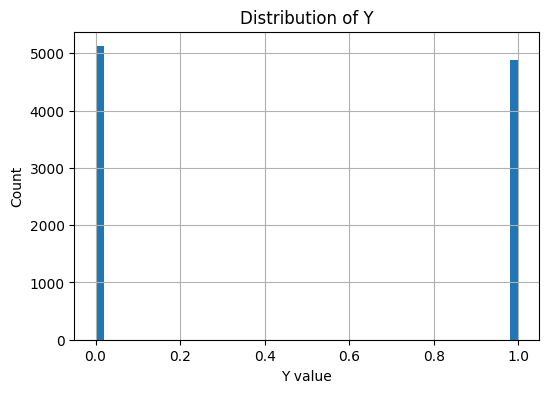

In [23]:
import numpy as np

with h5py.File(path, "r") as f:
    Y = f["Y"][:].squeeze()

print("Shape:", Y.shape)
print("dtype:", Y.dtype)
print("Min:", Y.min())
print("Max:", Y.max())
print("Unique values (first 20):", np.unique(Y)[:20])
print("Number of unique values:", len(np.unique(Y)))

# histogram
plt.figure(figsize=(6,4))
plt.hist(Y, bins=50)
plt.title("Distribution of Y")
plt.xlabel("Y value")
plt.ylabel("Count")
plt.grid(True)
plt.show()

In [24]:

path = "data/Dataset_Specific_labelled_full_only_for_2i.h5"

def explore(name, obj):
    if isinstance(obj, h5py.Dataset):
        print(f"{name} -> DATASET shape={obj.shape} dtype={obj.dtype}")
    else:
        print(f"{name} -> GROUP")

with h5py.File(path, "r") as f:
    print("Top-level keys:", list(f.keys()))
    print("\nFull structure:\n")
    f.visititems(explore)

with h5py.File(path, "r") as f:
    jet = f["jet"][0]
    print("Jet shape:", jet.shape)

    for k in f.keys():
        if k != "jet":
            print(k, "sample value:", f[k][0])

Top-level keys: ['Y', 'jet', 'm', 'pT']

Full structure:

Y -> DATASET shape=(10000, 1) dtype=float32
jet -> DATASET shape=(10000, 125, 125, 8) dtype=float32
m -> DATASET shape=(10000, 1) dtype=float32
pT -> DATASET shape=(10000, 1) dtype=float32
Jet shape: (125, 125, 8)
Y sample value: [1.]
m sample value: [136.34013]
pT sample value: [551.3493]


---------Y---------
Shape: (10000,)
dtype: float32
Min: 0.0
Max: 1.0
Unique values (first 20): [0. 1.]
Number of unique values: 2
---------m---------
Shape: (10000,)
dtype: float32
Min: 31.948496
Max: 728.3518
Unique values (first 20): [31.948496 37.162827 37.652603 38.178566 40.40662  42.476177 43.35503
 43.417694 44.285244 45.752937 46.323708 46.597603 46.610394 46.872013
 46.905388 46.91361  46.92877  46.98776  46.99083  47.015266]
Number of unique values: 9993
---------pT---------
Shape: (10000,)
dtype: float32
Min: 400.01608
Max: 2039.6335
Unique values (first 20): [400.01608 400.04034 400.05087 400.07315 400.0838  400.0869  400.2837
 400.2934  400.31705 400.34348 400.4446  400.46985 400.47272 400.48547
 400.48703 400.49677 400.51898 400.5383  400.53998 400.5431 ]
Number of unique values: 9984


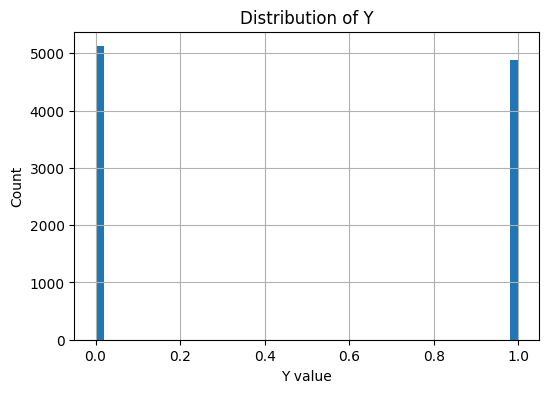

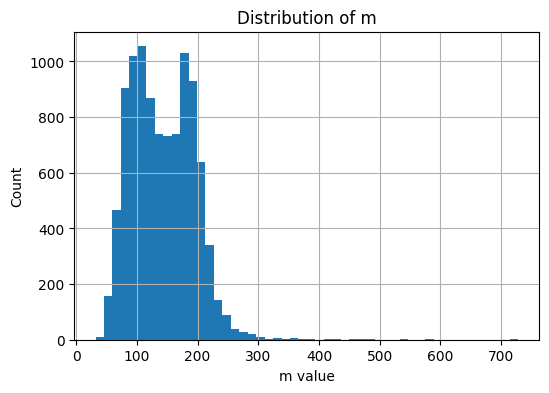

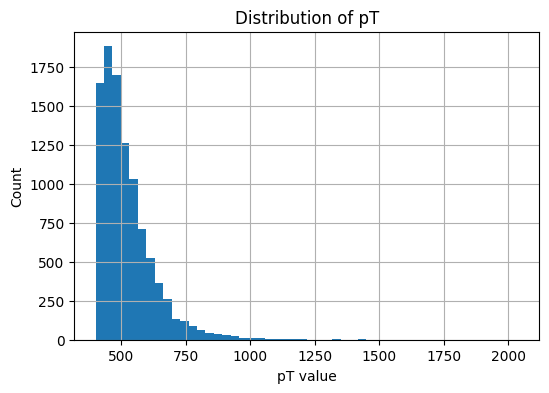

In [25]:
import numpy as np
import matplotlib.pyplot as plt

with h5py.File(path, "r") as f:
    Y = f["Y"][:].squeeze()
    m = f["m"][:].squeeze()
    pT = f["pT"][:].squeeze()

print("---------Y---------")
print("Shape:", Y.shape)
print("dtype:", Y.dtype)
print("Min:", Y.min())
print("Max:", Y.max())
print("Unique values (first 20):", np.unique(Y)[:20])
print("Number of unique values:", len(np.unique(Y)))

print("---------m---------")
print("Shape:", m.shape)
print("dtype:", m.dtype)
print("Min:", m.min())
print("Max:", m.max())
print("Unique values (first 20):", np.unique(m)[:20])
print("Number of unique values:", len(np.unique(m)))

print("---------pT---------")
print("Shape:", pT.shape)
print("dtype:", pT.dtype)
print("Min:", pT.min())
print("Max:", pT.max())
print("Unique values (first 20):", np.unique(pT)[:20])
print("Number of unique values:", len(np.unique(pT)))

# histogram
plt.figure(figsize=(6,4))
plt.hist(Y, bins=50)
plt.title("Distribution of Y")
plt.xlabel("Y value")
plt.ylabel("Count")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.hist(m, bins=50)
plt.title("Distribution of m")
plt.xlabel("m value")
plt.ylabel("Count")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.hist(pT, bins=50)
plt.title("Distribution of pT")
plt.xlabel("pT value")
plt.ylabel("Count")
plt.grid(True)
plt.show()

## Fine-tuning for Binary Classification

The labelled dataset contains:

- jet: (10000, 125, 125, 8)
- Y:   binary labels {0,1}

We therefore treat this as a binary classification task.

Procedure:
1. 80% train / 20% test split
2. Fine-tune pretrained encoder with low learning rate
3. Train identical model from scratch
4. Compare test accuracy and training dynamics

Loss: Binary Cross Entropy with Logits
Metric: Accuracy

In [26]:
import h5py
import torch
from torch.utils.data import Dataset, DataLoader, random_split

class JetDataset(Dataset):
    def __init__(self, h5_path, task="cls"):
        self.h5_path = h5_path
        self.file = None
        self.task = task

        with h5py.File(h5_path, "r") as f:
            self.length = f["jet"].shape[0]
            self.available_keys = set(f.keys())

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        if self.file is None:
            self.file = h5py.File(self.h5_path, "r")

        x = self.file["jet"][idx]
        x = torch.tensor(x, dtype=torch.float32).permute(2, 0, 1)
        x = (x - x.mean()) / (x.std() + 1e-6)

        if self.task == "cls":
            y = self.file["Y"][idx]
        elif self.task == "mass":
            if "m" not in self.available_keys:
                raise KeyError("Dataset missing key 'm' for mass regression")
            y = self.file["m"][idx]
        elif self.task == "pt":
            if "pT" not in self.available_keys:
                raise KeyError("Dataset missing key 'pT' for pT regression")
            y = self.file["pT"][idx]
        else:
            raise ValueError(f"Unknown task: {self.task}")

        y = torch.tensor(y, dtype=torch.float32).squeeze()
        return x, y

In [27]:
def make_loaders(task, batch_size=32, val_frac_from_train=0.1):
    dataset = JetDataset("data/Dataset_Specific_labelled_full_only_for_2i.h5", task)

    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size

    train_full, test_ds = random_split(
        dataset,
        [train_size, test_size],
        generator=torch.Generator().manual_seed(42)
    )

    val_size = int(val_frac_from_train * len(train_full))
    val_size = max(1, val_size)
    train_size_final = len(train_full) - val_size

    train_ds, val_ds = random_split(
        train_full,
        [train_size_final, val_size],
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

In [28]:
import torch.nn as nn

class FinetuneModel(nn.Module):
    def __init__(self, encoder, out_dim=1):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Linear(256, out_dim)

    def forward(self, x):
        z = self.encoder(x).mean(dim=1)
        return self.head(z)

In [29]:
import numpy as np
import copy
import os

torch.manual_seed(42)
np.random.seed(42)

os.makedirs("weights", exist_ok=True)

def build_model(pretrained=True):
    encoder = Encoder().to(device)
    if pretrained:
        state = torch.load("pretrained_encoder.pt", map_location=device)
        encoder.load_state_dict(state)
    return FinetuneModel(encoder).to(device)

In [30]:
from tqdm import tqdm
import matplotlib.pyplot as plt

def evaluate_regression(model, loader):
    model.eval()
    total_loss = 0.0
    criterion = nn.MSELoss()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device).float().view(-1)
            pred = model(x).squeeze(-1)
            loss = criterion(pred, y)
            total_loss += loss.item()
    return total_loss / max(1, len(loader))

def evaluate_classification(model, loader):
    model.eval()
    criterion = nn.BCEWithLogitsLoss()
    total_loss = 0.0
    logits_all, labels_all = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device).float().view(-1)
            logits = model(x).squeeze(-1)
            loss = criterion(logits, y)

            total_loss += loss.item()
            logits_all.append(logits.detach().cpu())
            labels_all.append(y.detach().cpu())

    logits_all = torch.cat(logits_all).numpy()
    labels_all = torch.cat(labels_all).numpy()
    probs = 1.0 / (1.0 + np.exp(-logits_all))
    preds = (probs >= 0.5).astype(np.int32)

    return {
        "loss": total_loss / max(1, len(loader)),
        "labels": labels_all.astype(np.int32),
        "probs": probs,
        "preds": preds,
    }

def train_and_eval(task, pretrained=True, lr=1e-4, epochs=12, patience=3):
    train_loader, val_loader, test_loader = make_loaders(task)
    model = build_model(pretrained=pretrained)

    is_cls = task == "cls"
    criterion = nn.BCEWithLogitsLoss() if is_cls else nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    history = {"train": [], "val": []}
    best_state = None
    best_val = float("inf")
    bad_epochs = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for x, y in tqdm(train_loader, leave=False, desc=f"{task} ep {epoch+1}/{epochs}"):
            x = x.to(device)
            y = y.to(device).float().view(-1)

            out = model(x).squeeze(-1)
            loss = criterion(out, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= max(1, len(train_loader))

        if is_cls:
            val_metrics = evaluate_classification(model, val_loader)
            val_loss = val_metrics["loss"]
        else:
            val_loss = evaluate_regression(model, val_loader)

        history["train"].append(train_loss)
        history["val"].append(val_loss)

        improved = val_loss < best_val
        if improved:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        print(f"{task} | {'pre' if pretrained else 'scratch'} | epoch {epoch+1} | train={train_loss:.4f} | val={val_loss:.4f}")

        if bad_epochs >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    if is_cls:
        test_metrics = evaluate_classification(model, test_loader)
    else:
        test_metrics = {"loss": evaluate_regression(model, test_loader)}

    tag = "pretrained" if pretrained else "scratch"
    torch.save(model.state_dict(), f"weights/{task}_{tag}_finetune.pt")

    return history, test_metrics

## Experiment: Pretrained vs Scratch (Classification, Mass, pT)

This experiment follows the requested protocol:

- 80% labelled data for model development, 20% held-out test
- Inside the 80%, we use a train/validation split for early stopping
- We train and compare **pretrained** vs **scratch** models for:
  - Classification (`Y`)
  - Mass regression (`m`)
  - pT regression (`pT`)

For classification, we additionally report:

- Confusion matrix (TN, FP, FN, TP)
- ROC-AUC score
- ROC curve

/tmp/ipykernel_4066756/1858435518.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load("pretrained_encoder.pt", map_location=device)


Classification: Pretrained


cls ep 1/12:   0%|          | 0/225 [00:00<?, ?it/s]

cls | pre | epoch 1 | train=0.6380 | val=0.5850


cls | pre | epoch 2 | train=0.5919 | val=0.5621


...

pt | scratch | epoch 8 | train=205214.8519 | val=198985.5469


pt | scratch | epoch 9 | train=194379.8926 | val=188091.4150


pt | scratch | epoch 10 | train=183386.7850 | val=177082.6250


pt | scratch | epoch 11 | train=172315.3528 | val=166017.9438


pt | scratch | epoch 12 | train=161238.9925 | val=154998.2834


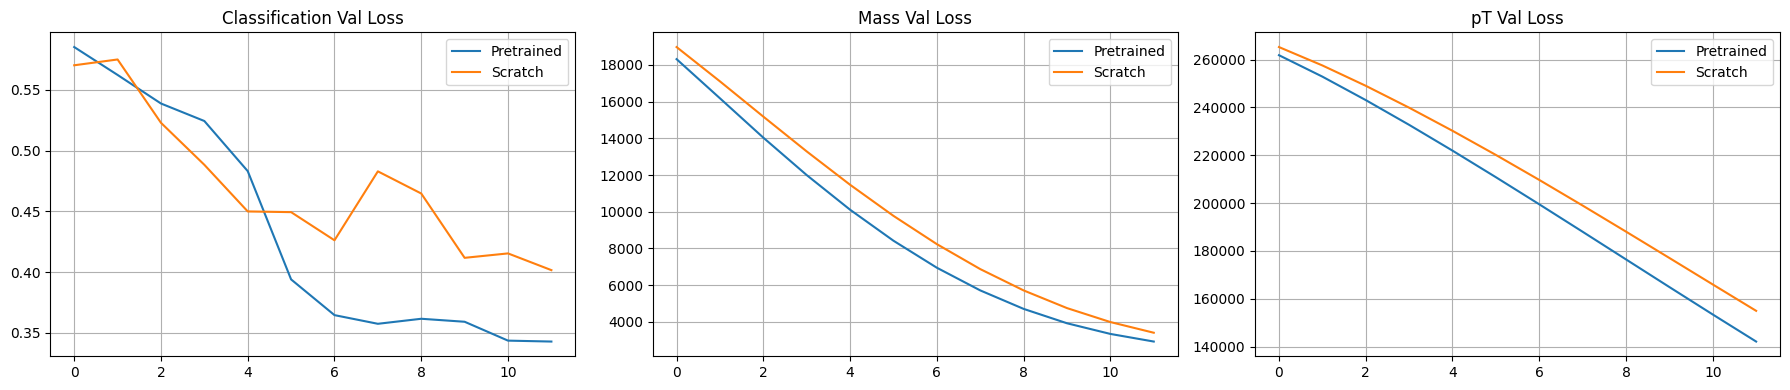


Pretrained Classification Test Metrics
Loss: 0.3857
Accuracy: 0.8410
TN=795, FP=220, FN=98, TP=887
ROC-AUC: 0.9042

Scratch Classification Test Metrics
Loss: 0.4177
Accuracy: 0.8220
TN=854, FP=161, FN=195, TP=790
ROC-AUC: 0.8906


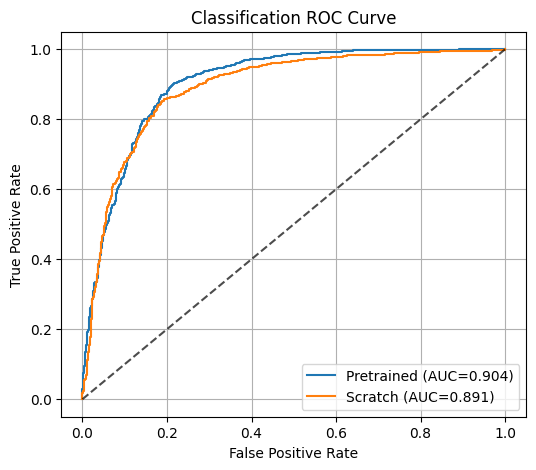


Regression Test MSE
Mass  | Pretrained: 3517.8008 | Scratch: 3977.2033
pT    | Pretrained: 148184.0350 | Scratch: 161189.8982


In [32]:
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# --------- Run all tasks ---------
print("Classification: Pretrained")
cls_pre_hist, cls_pre_test = train_and_eval("cls", pretrained=True, lr=1e-4, epochs=12, patience=3)

print("Classification: Scratch")
cls_scratch_hist, cls_scratch_test = train_and_eval("cls", pretrained=False, lr=1e-4, epochs=12, patience=3)

print("Mass: Pretrained")
mass_pre_hist, mass_pre_test = train_and_eval("mass", pretrained=True, lr=1e-4, epochs=12, patience=3)

print("Mass: Scratch")
mass_scratch_hist, mass_scratch_test = train_and_eval("mass", pretrained=False, lr=1e-4, epochs=12, patience=3)

print("pT: Pretrained")
pt_pre_hist, pt_pre_test = train_and_eval("pt", pretrained=True, lr=1e-4, epochs=12, patience=3)

print("pT: Scratch")
pt_scratch_hist, pt_scratch_test = train_and_eval("pt", pretrained=False, lr=1e-4, epochs=12, patience=3)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(cls_pre_hist["val"], label="Pretrained")
axes[0].plot(cls_scratch_hist["val"], label="Scratch")
axes[0].set_title("Classification Val Loss")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(mass_pre_hist["val"], label="Pretrained")
axes[1].plot(mass_scratch_hist["val"], label="Scratch")
axes[1].set_title("Mass Val Loss")
axes[1].grid(True)
axes[1].legend()

axes[2].plot(pt_pre_hist["val"], label="Pretrained")
axes[2].plot(pt_scratch_hist["val"], label="Scratch")
axes[2].set_title("pT Val Loss")
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

for name, out in [("Pretrained", cls_pre_test), ("Scratch", cls_scratch_test)]:
    tn, fp, fn, tp = confusion_matrix(out["labels"], out["preds"]).ravel()
    auc = roc_auc_score(out["labels"], out["probs"])
    acc = (out["preds"] == out["labels"]).mean()

    print(f"\n{name} Classification Test Metrics")
    print(f"Loss: {out['loss']:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
    print(f"ROC-AUC: {auc:.4f}")

# ROC curves
fpr_pre, tpr_pre, _ = roc_curve(cls_pre_test["labels"], cls_pre_test["probs"])
fpr_scr, tpr_scr, _ = roc_curve(cls_scratch_test["labels"], cls_scratch_test["probs"])
auc_pre = roc_auc_score(cls_pre_test["labels"], cls_pre_test["probs"])
auc_scr = roc_auc_score(cls_scratch_test["labels"], cls_scratch_test["probs"] )

plt.figure(figsize=(6, 5))
plt.plot(fpr_pre, tpr_pre, label=f"Pretrained (AUC={auc_pre:.3f})")
plt.plot(fpr_scr, tpr_scr, label=f"Scratch (AUC={auc_scr:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.7)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Classification ROC Curve")
plt.grid(True)
plt.legend()
plt.show()

print("\nRegression Test MSE")
print(f"Mass  | Pretrained: {mass_pre_test['loss']:.4f} | Scratch: {mass_scratch_test['loss']:.4f}")
print(f"pT    | Pretrained: {pt_pre_test['loss']:.4f} | Scratch: {pt_scratch_test['loss']:.4f}")